In [22]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
sys.path.append('/nird/projects/NS9873K/emile/unseen-storm-forecasts')

import xarray as xr
import numpy as np

In [23]:
import test_fidelity as fid
import test_independence as ind
import test_stability as stab

Checking raw data tests

In [24]:
processed = xr.open_dataarray("processed-july.nc")
maxs = xr.open_dataarray("maxs-july.nc")

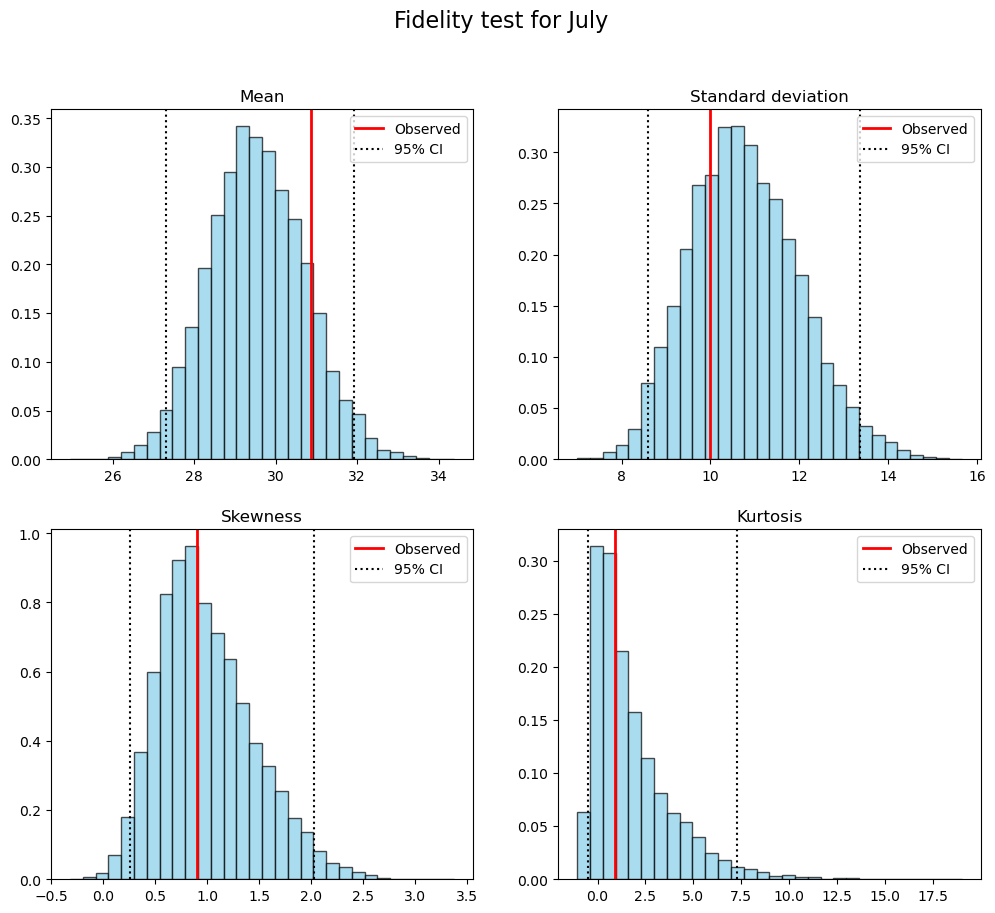

In [25]:
rea, mod = fid.main("maxs-july.nc", "../../data/processed-rea.nc")
fid.plot(rea, mod, "raw", "July", show=True)

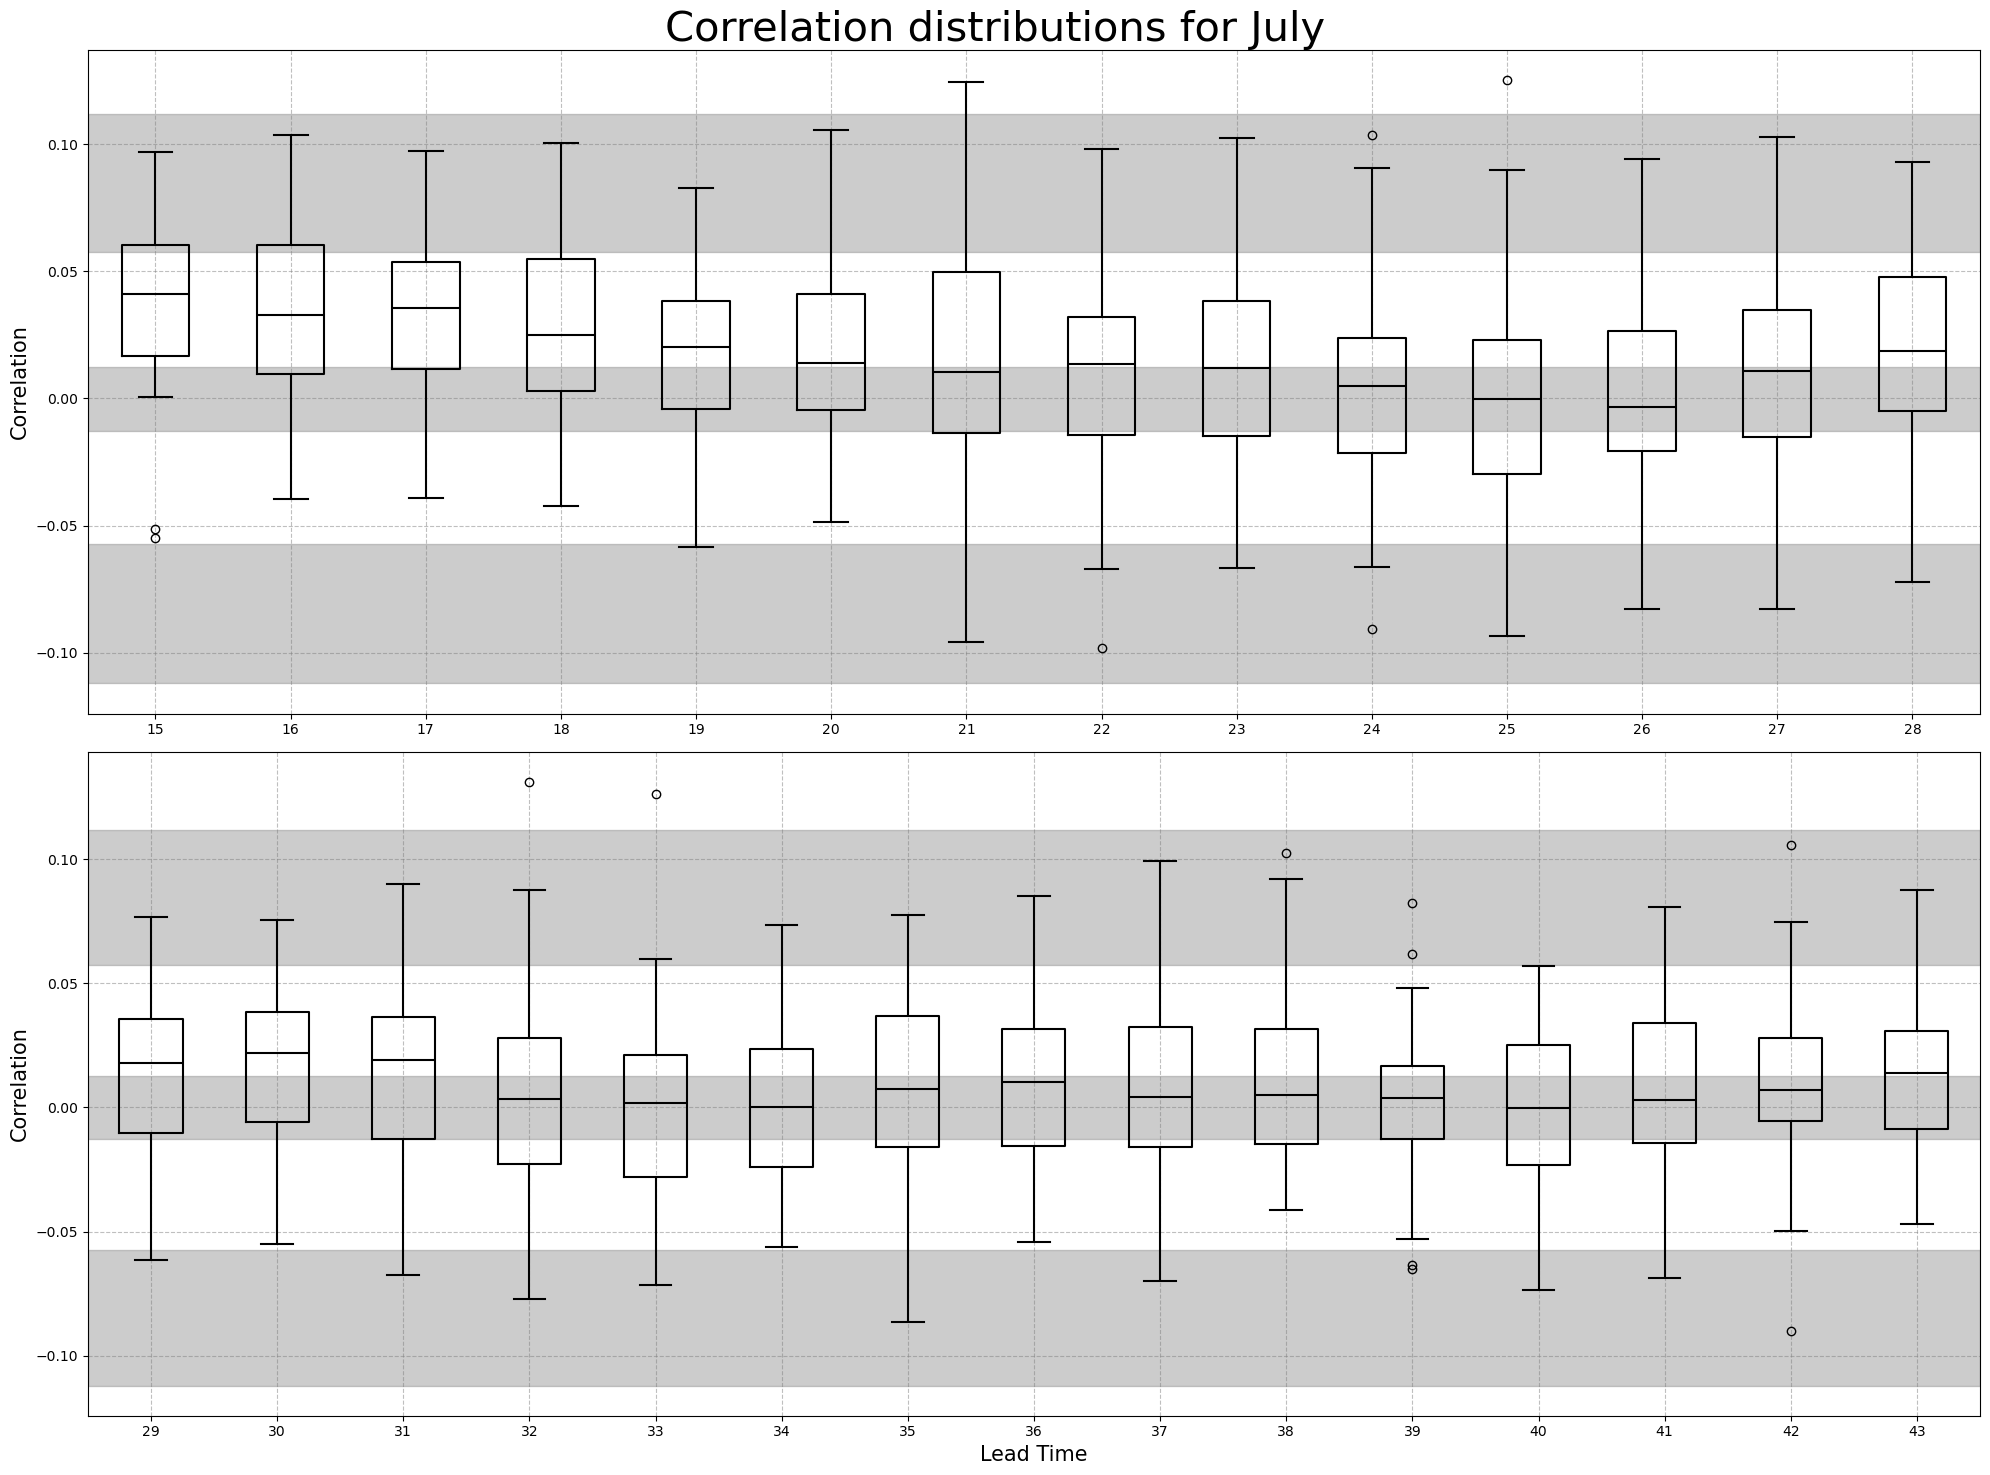

In [26]:
corr, interv = ind.correlation(processed)
ind.plot_correlations(corr, interv, "raw",show=True)

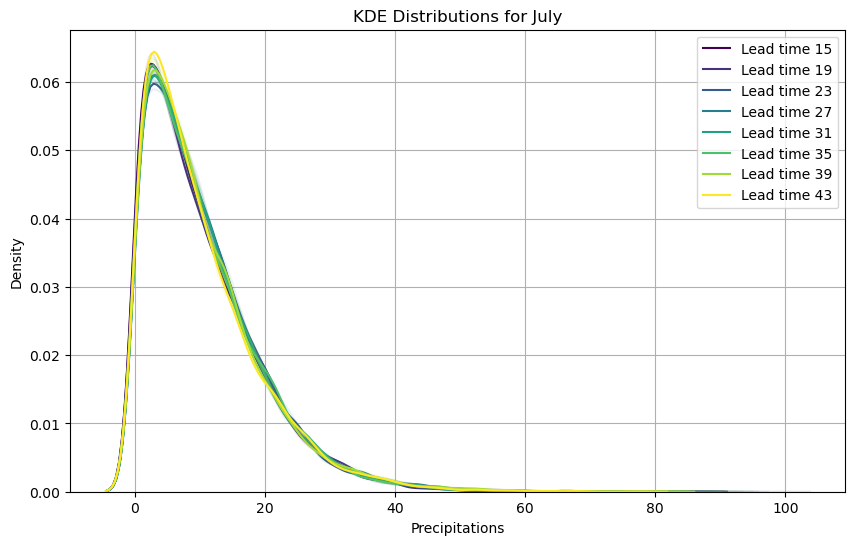

In [27]:
stab.plot_kde_distributions(processed, "raw", show=True)

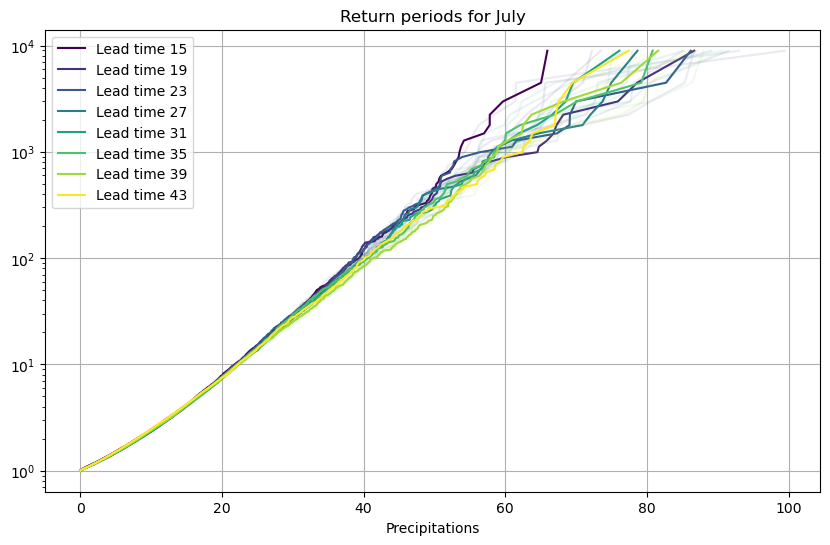

In [28]:
stab.plot_return_period(processed, "raw", show=True)

### Fidelity correction

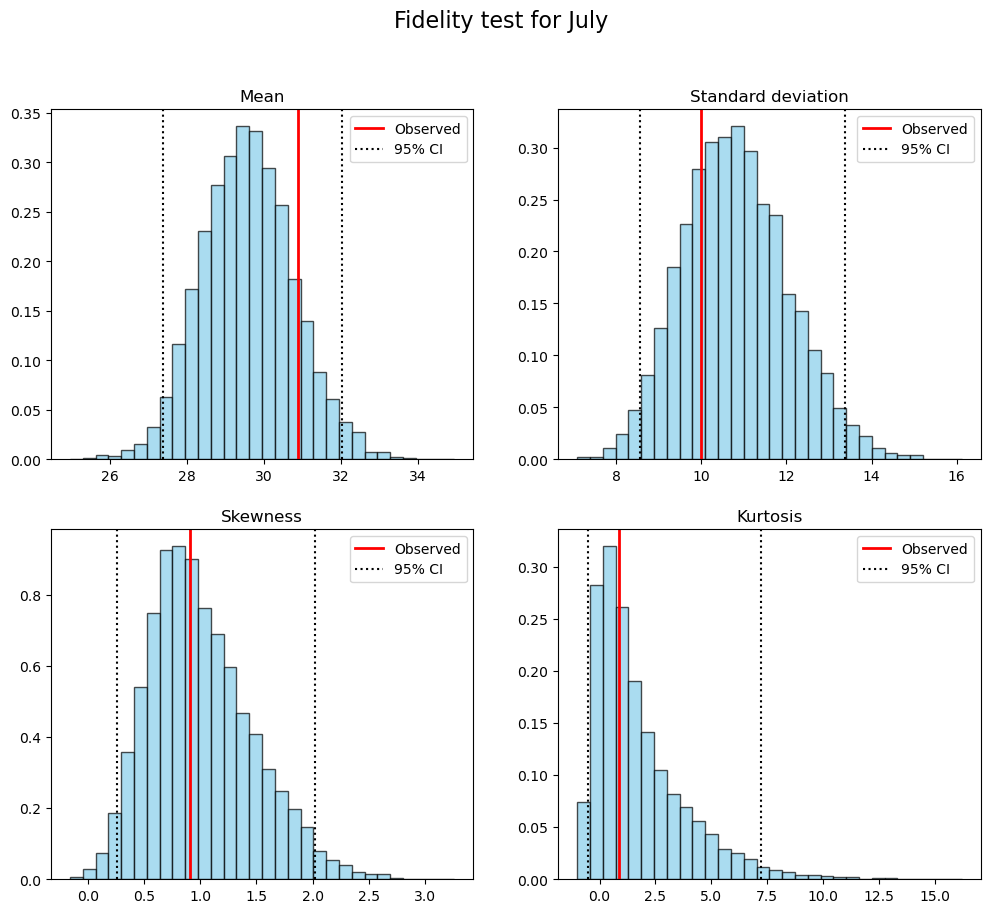

In [40]:
rea, mod = fid.main(
    "maxs-july.nc", "../../data/processed-rea.nc"
)
fid.plot(rea, mod, "", "July", show=True)

In [ ]:
maxs_corrected_2 = maxs + 1.5
corrected_2 = processed + 1.5

In [42]:
corrected_2.to_netcdf("corrected_2.nc")
maxs_corrected_2.to_netcdf("maxs_corrected_2.nc")

### Final test

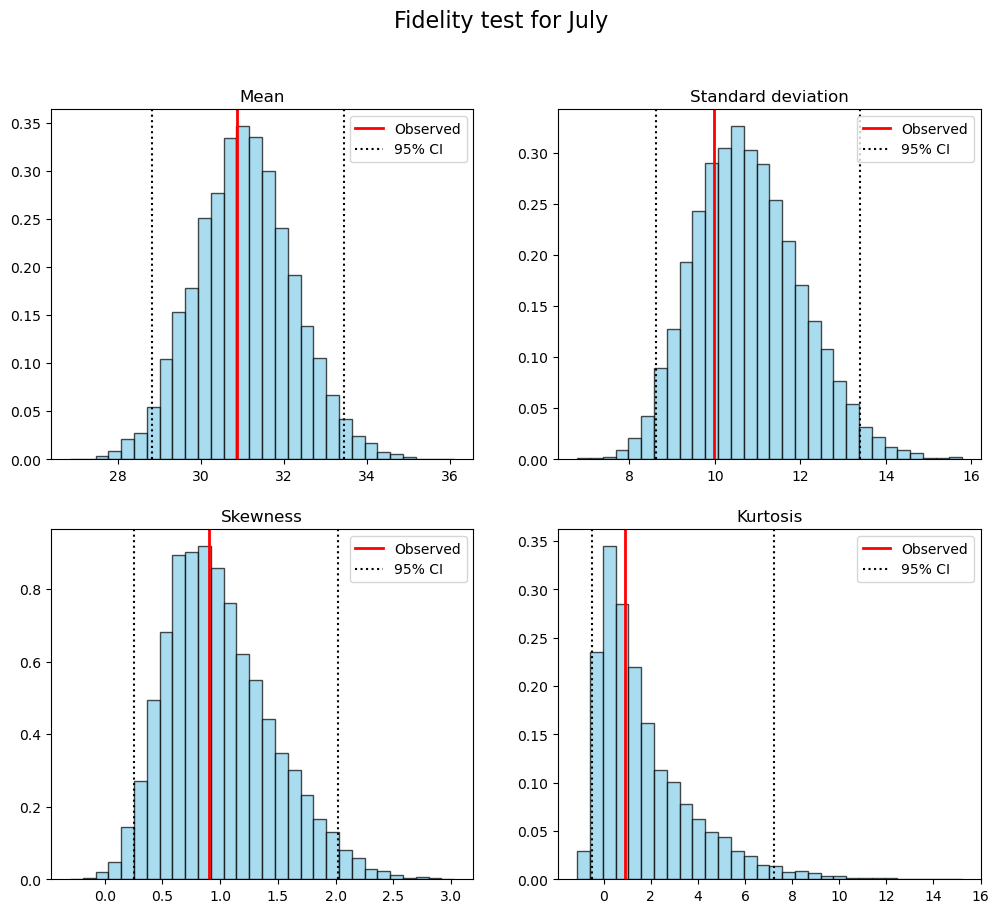

In [43]:
rea, mod = fid.main(
    "maxs_corrected_2.nc", "../../data/processed-rea.nc"
)
fid.plot(rea, mod, "", "July", show=True)

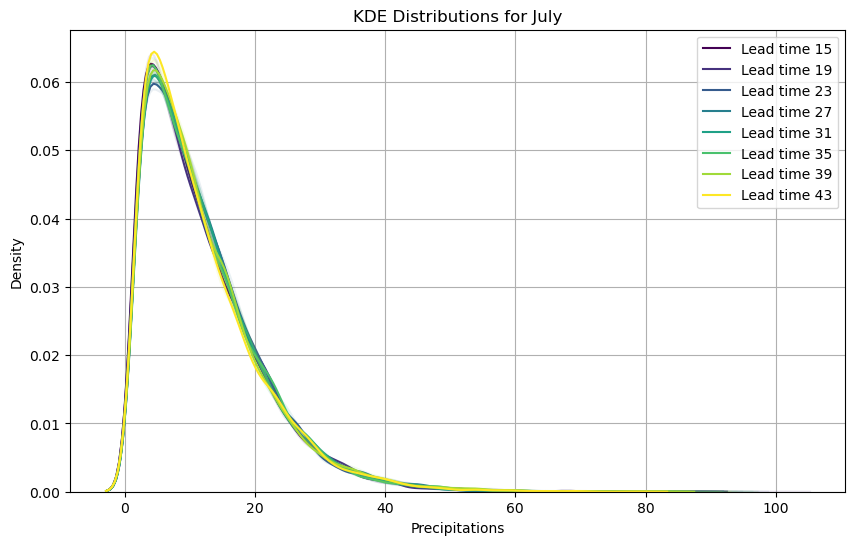

In [44]:
stab.plot_kde_distributions(
    corrected_2, "", show=True
)

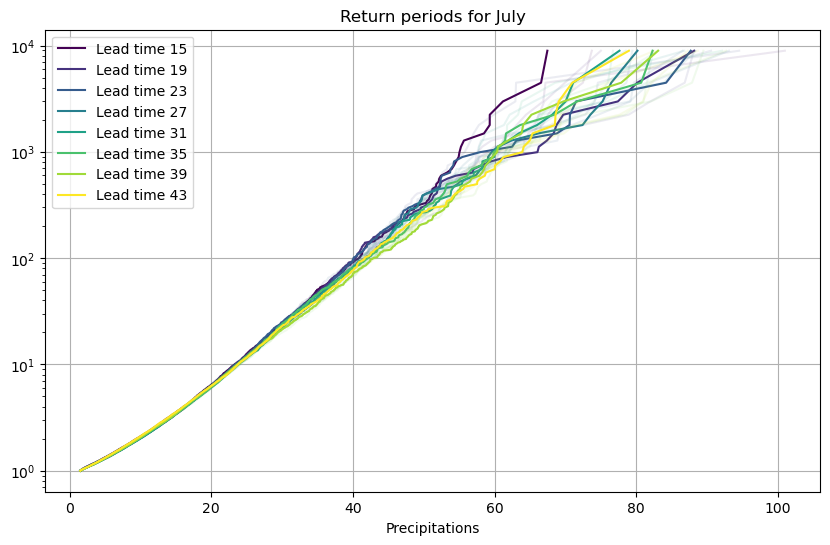

In [45]:
stab.plot_return_period(
    corrected_2, "", show=True
)

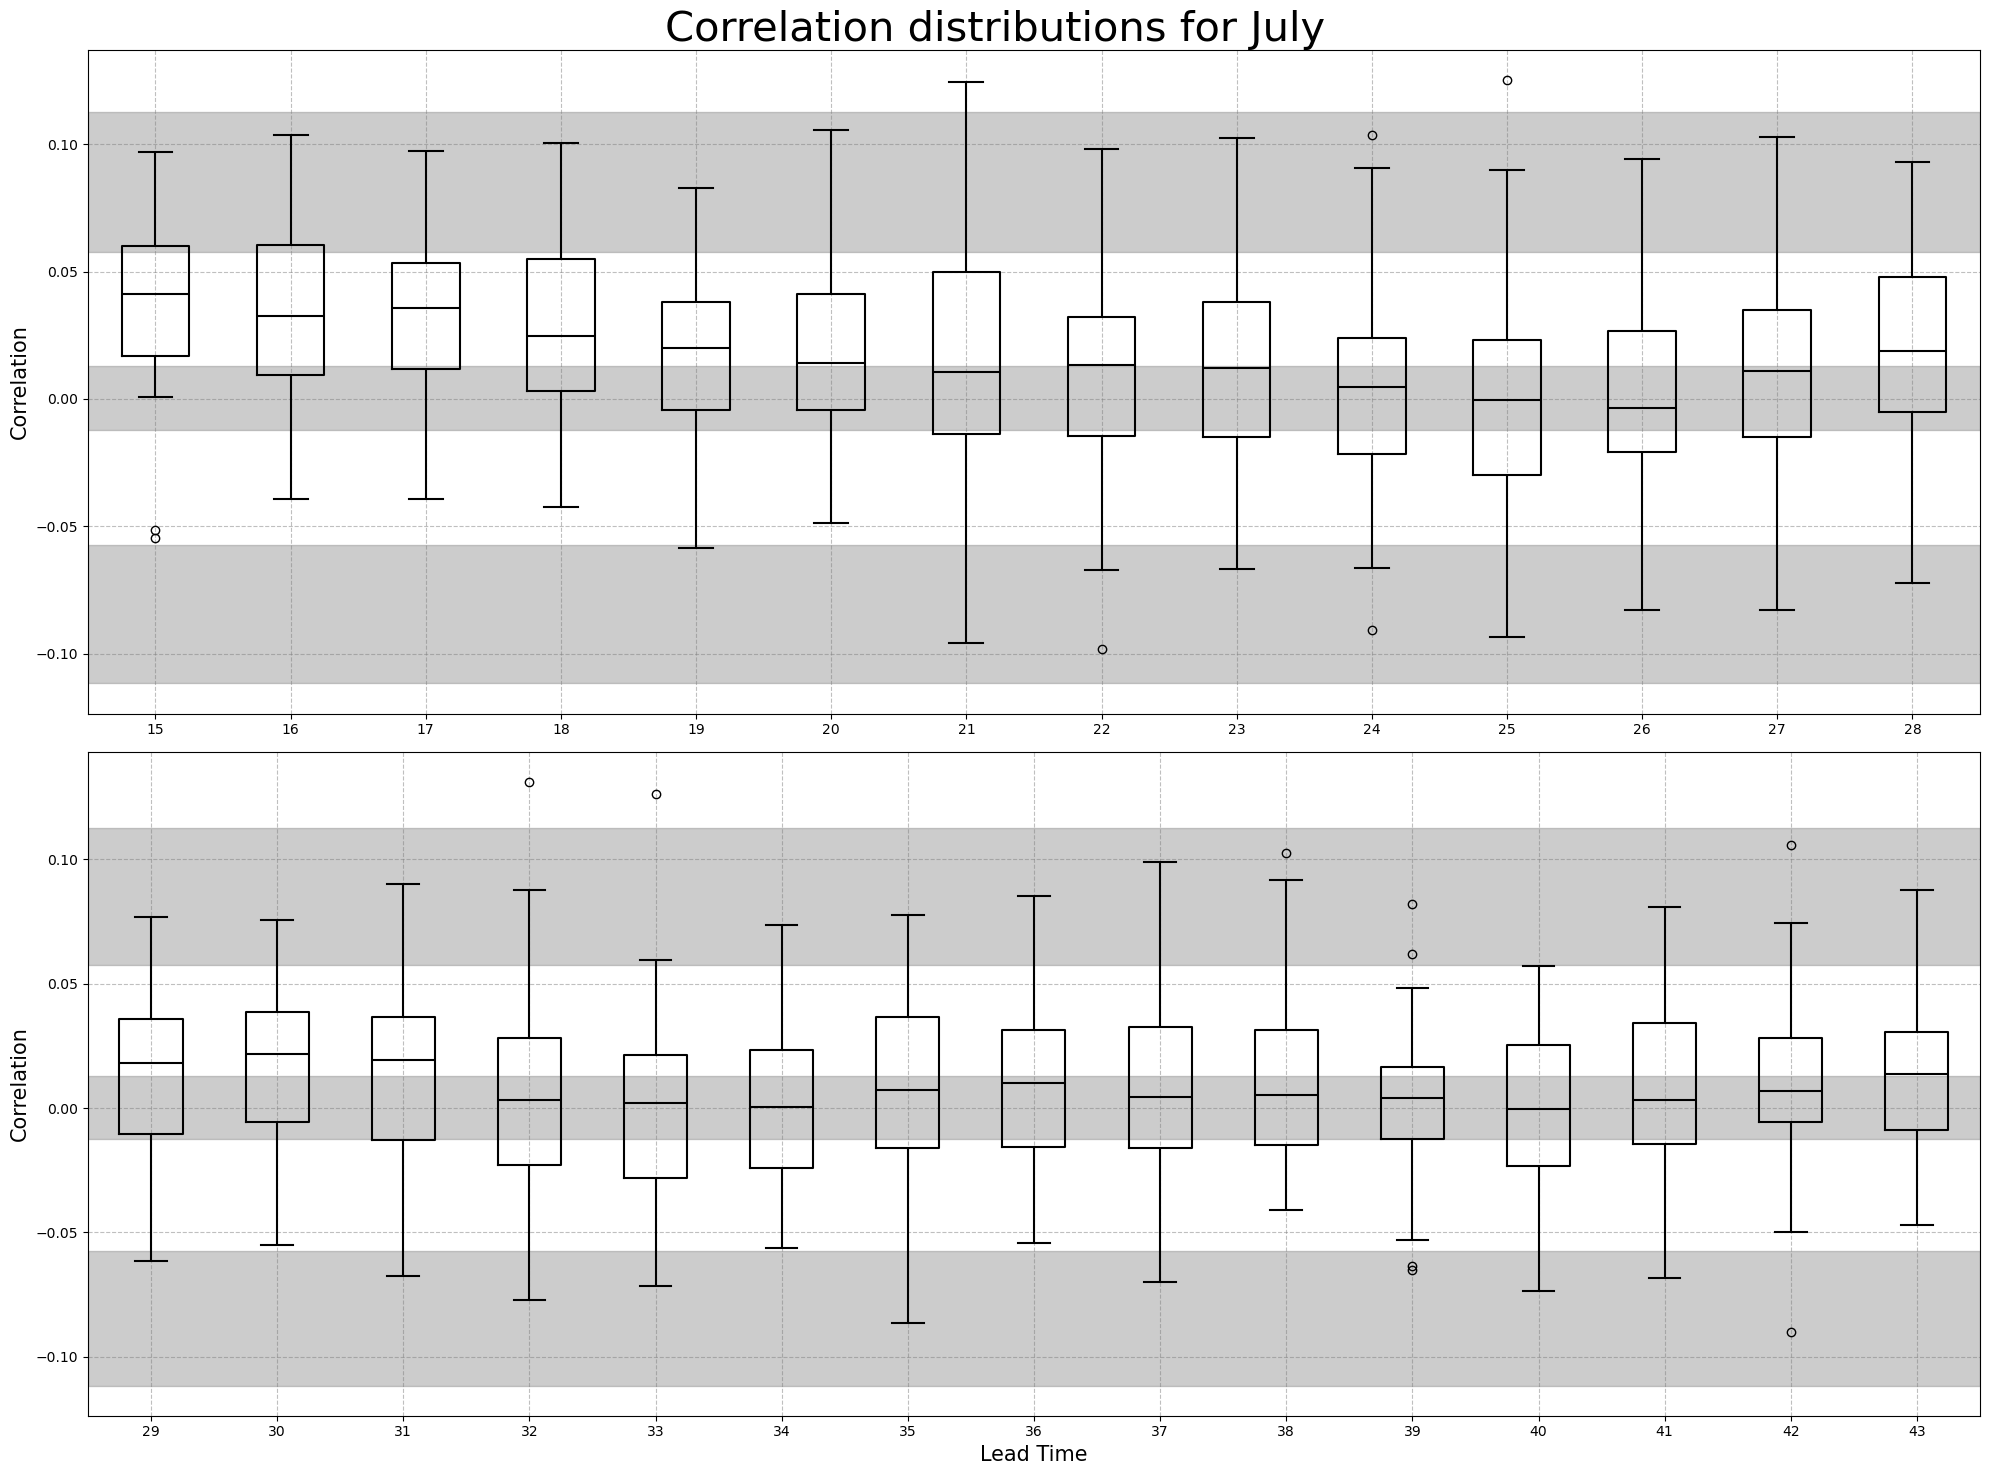

In [46]:
corr, interv = ind.correlation(corrected_2)
ind.plot_correlations(corr, interv, "", show=True)